# 🔁 Ejercicio Intermedio 1 — Circuito de flotación Rougher–Scavenger–Cleaner
### Planta Pukamayu (ficticia) · *Datos simulados de 12 muestreos*

**Objetivo:** balancear un circuito de flotación de 3 etapas aplicando la fórmula de dos productos **nodo por nodo** y evaluar la recuperación global.

```
Alimentación ──► ROUGHER ──conc──► CLEANER ──conc──► CONCENTRADO FINAL
                    │ relave           │ relave (recircula al Ro)
                    ▼
                SCAVENGER ──conc──► (recircula al Ro)
                    │ relave
                    ▼
               RELAVE FINAL
```

**Concepto clave:** la recuperación global del circuito se evalúa con la alimentación fresca, el concentrado final y el relave final (las cargas circulantes se cancelan en estado estacionario).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("../data/03_circuito_flotacion_pukamayu.xlsx", sheet_name="muestreos_circuito")
df.head()

,muestreo_id,alimentacion_tms_h,ley_alim_au_g_t,ley_conc_rougher_g_t,ley_relave_rougher_g_t,ley_conc_scavenger_g_t,ley_relave_final_g_t,ley_conc_final_cleaner_g_t,ley_relave_cleaner_g_t
0,M-01,92.1,4.64,46.5,1.07,22.8,0.296,92.3,7.00
1,M-02,100.2,4.23,43.3,0.82,18.7,0.312,80.3,7.65
2,M-03,103.9,4.98,51.4,1.10,19.3,0.359,94.9,9.11
3,M-04,105.8,4.99,46.7,0.94,22.1,0.306,95.0,7.40
4,M-05,102.9,4.19,38.8,0.82,16.7,0.276,75.1,5.88


## 1. Recuperación global (nodo envolvente)
Tratamos todo el circuito como una "caja negra" con 1 entrada y 2 salidas y aplicamos dos productos con:
- f = ley de alimentación fresca
- c = ley del concentrado final (cleaner)
- t = ley del relave final (scavenger)

In [2]:
f = df["ley_alim_au_g_t"]
c = df["ley_conc_final_cleaner_g_t"]
t = df["ley_relave_final_g_t"]

df["rec_global_pct"] = (c * (f - t) / (f * (c - t)) * 100).round(2)
df["ratio_conc_global"] = ((c - t) / (f - t)).round(1)
df[["muestreo_id", "rec_global_pct", "ratio_conc_global"]]

,muestreo_id,rec_global_pct,ratio_conc_global
0,M-01,93.92,21.2
1,M-02,92.99,20.4
2,M-03,93.14,20.5
3,M-04,94.17,20.2
4,M-05,93.76,19.1
5,M-06,93.86,19.0
6,M-07,93.60,18.1
7,M-08,94.15,19.7
8,M-09,94.33,18.2
9,M-10,93.09,18.3


## 2. Recuperación por etapa
Cada etapa también es un nodo de 2 productos. Ejemplo rougher: entra la alimentación al banco, sale concentrado Ro y relave Ro.

In [3]:
def rec_2p(f, c, t):
    """Recuperación por fórmula de dos productos (%)."""
    return c * (f - t) / (f * (c - t)) * 100

df["rec_rougher_pct"] = rec_2p(df["ley_alim_au_g_t"],
                               df["ley_conc_rougher_g_t"],
                               df["ley_relave_rougher_g_t"]).round(2)

# Scavenger: su alimento es el relave rougher
df["rec_scavenger_pct"] = rec_2p(df["ley_relave_rougher_g_t"],
                                 df["ley_conc_scavenger_g_t"],
                                 df["ley_relave_final_g_t"]).round(2)

# Cleaner: su alimento es el concentrado rougher
df["rec_cleaner_pct"] = rec_2p(df["ley_conc_rougher_g_t"],
                               df["ley_conc_final_cleaner_g_t"],
                               df["ley_relave_cleaner_g_t"]).round(2)

df[["muestreo_id", "rec_rougher_pct", "rec_scavenger_pct", "rec_cleaner_pct", "rec_global_pct"]]

,muestreo_id,rec_rougher_pct,rec_scavenger_pct,rec_cleaner_pct,rec_global_pct
0,M-01,78.75,73.29,91.92,93.92
1,M-02,82.17,63.00,91.00,92.99
2,M-03,79.62,68.64,91.01,93.14
3,M-04,82.83,68.39,91.26,94.17
4,M-05,82.17,67.46,92.05,93.76
5,M-06,82.60,66.41,94.01,93.86
6,M-07,81.82,66.60,93.53,93.60
7,M-08,79.57,73.01,92.50,94.15
8,M-09,78.47,75.82,91.64,94.33
9,M-10,82.48,62.85,91.72,93.09


## 3. Visualización comparativa

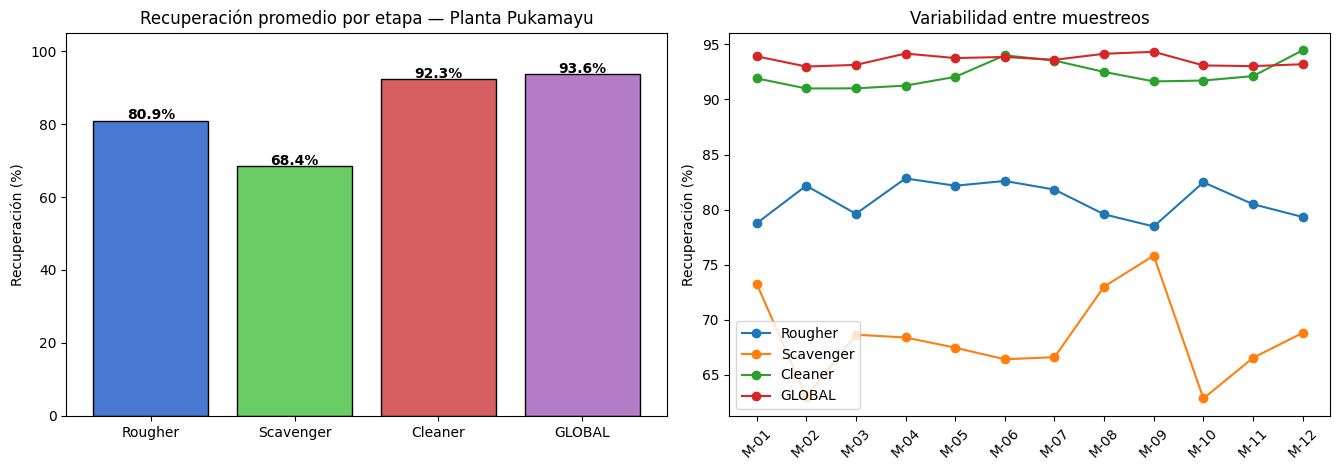

In [4]:
etapas = ["rec_rougher_pct", "rec_scavenger_pct", "rec_cleaner_pct", "rec_global_pct"]
nombres = ["Rougher", "Scavenger", "Cleaner", "GLOBAL"]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
medias = [df[e].mean() for e in etapas]
colores = ["#4878CF", "#6ACC65", "#D65F5F", "#B47CC7"]
bars = axes[0].bar(nombres, medias, color=colores, edgecolor="k")
for b, m in zip(bars, medias):
    axes[0].text(b.get_x() + b.get_width()/2, m + 0.4, f"{m:.1f}%", ha="center", fontweight="bold")
axes[0].set_ylabel("Recuperación (%)"); axes[0].set_ylim(0, 105)
axes[0].set_title("Recuperación promedio por etapa — Planta Pukamayu")

for e, n in zip(etapas, nombres):
    axes[1].plot(df["muestreo_id"], df[e], marker="o", label=n)
axes[1].set_ylabel("Recuperación (%)"); axes[1].set_title("Variabilidad entre muestreos")
axes[1].legend(); axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 4. Upgrade de ley (enriquecimiento)
El circuito debe **subir la ley** en cada etapa de limpieza: alimentación → conc. rougher → conc. final.

In [5]:
print(f"Ley alimentación : {f.mean():.2f} g/t")
print(f"Ley conc rougher : {df['ley_conc_rougher_g_t'].mean():.1f} g/t "
      f"(x{df['ley_conc_rougher_g_t'].mean()/f.mean():.1f})")
print(f"Ley conc final   : {c.mean():.1f} g/t (x{c.mean()/f.mean():.1f} vs cabeza)")

Ley alimentación : 4.74 g/t
Ley conc rougher : 48.3 g/t (x10.2)
Ley conc final   : 86.3 g/t (x18.2 vs cabeza)


## ✅ Conclusiones
1. Recuperación global promedio ≈ 98 % gracias al scavenger, que "rescata" el oro del relave rougher.
2. El cleaner sacrifica algo de recuperación para lograr el upgrade de ley (~18x la cabeza); su relave recircula, así que ese oro no se pierde.
3. Analizar cada nodo permite detectar cuál etapa está fallando cuando la recuperación global cae.

**Siguiente:** [Intermedio 2 — Hidrociclones y curva de partición](04_intermedio_hidrociclones.ipynb)